In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('C:/Users/nmims.student/Electric_Production.csv')
df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [5]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE')

In [6]:
df.head()

,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'IPG2211A2N')

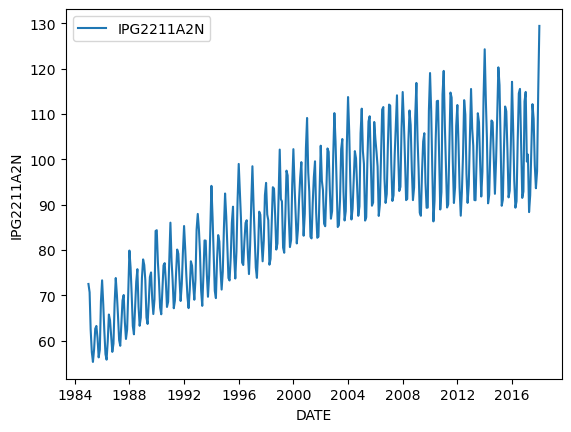

In [7]:
sns.lineplot(df)
plt.ylabel('IPG2211A2N')

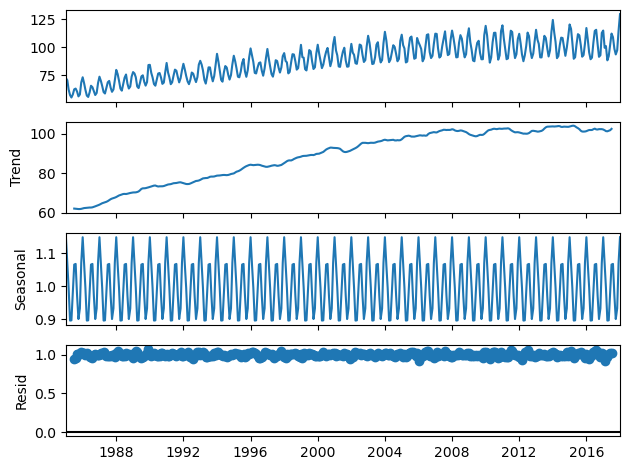

In [8]:
result = seasonal_decompose(df[['IPG2211A2N']], model='multiplicative')
result.plot()
plt.show()

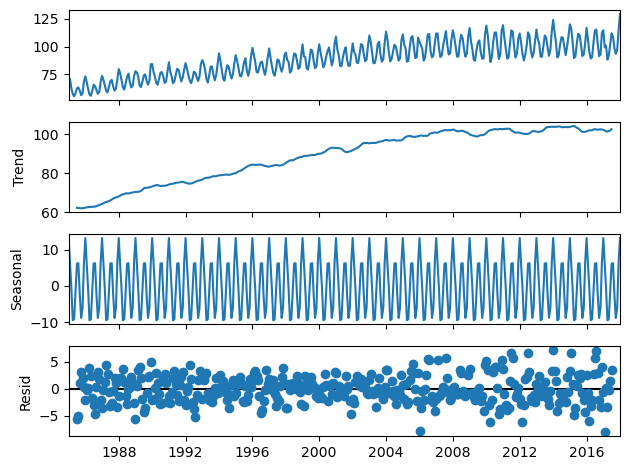

In [9]:
result = seasonal_decompose(df[['IPG2211A2N']], model='additive')
result.plot()
plt.show()

In [10]:
pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pymannkendall as mk

#perform Mann-Kendall test
#H0: There is no monotonic trend in the series

mk.original_test(df['IPG2211A2N'])

Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=19.125339232804578, Tau=0.6427499173091112, s=50524.0, var_s=6978466.0, slope=0.11486610139860137, intercept=67.03601192307693)

In [12]:
#p-value<0.5 reject H0 there is a trend present
train_df = df[:int(df.shape[0]*0.7)]
test_df = df[int(df.shape[0]*0.7):]

In [13]:
train_df.shape

(277, 1)

In [14]:
#Triple Exponential Smoothing

from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(train_df, seasonal_periods = 12, trend='add', seasonal='add')
model_triple_fit = model_triple.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [15]:
forecast_triple = model_triple_fit.forecast(6)
print(forecast_triple)

2008-02-01    109.875492
2008-03-01    102.218329
2008-04-01     92.951407
2008-05-01     94.533240
2008-06-01    103.490456
2008-07-01    111.228556
Freq: MS, dtype: float64


In [16]:
forecast_triple = model_triple_fit.forecast(40)
model_triple_fit.params

{'smoothing_level': 0.39353257738362746,
 'smoothing_trend': 0.0,
 'smoothing_seasonal': 0.26011863530030677,
 'damping_trend': nan,
 'initial_level': 62.43279730454734,
 'initial_trend': 0.144956818052901,
 'initial_seasons': array([10.27486804,  6.42520513,  0.35967342, -5.34731735, -6.63722442,
        -2.37084929,  2.5454322 ,  2.43636259, -2.31114285, -6.18830092,
        -4.08324674,  5.43597514]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

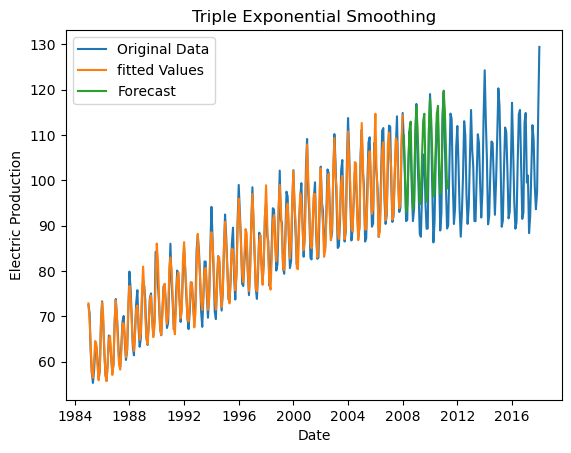

In [17]:
plt.plot(df,label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Electric Production')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [18]:
#Practical-2 Checking Stationary
#ADF Test
#h0-series is not stationary vs h1-series is stationary

In [19]:
from statsmodels.tsa.stattools import adfuller
print('Results of the Dickey Fuller Test:')
dftest = adfuller(df['IPG2211A2N'])
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#not stationary

Results of the Dickey Fuller Test:
Test Statistic             -2.256990
P-value                     0.186215
#Lags used                 15.000000
Number of Observations    381.000000
Critical Value(1%)         -3.447631
Critical Value(5%)         -2.869156
Critical Value(10%)        -2.570827
dtype: float64


In [20]:
#KPSS Test
#h0-series is stationary vs h1-series is not stationary

In [21]:
from statsmodels.tsa.stattools import kpss
kp = kpss(df['IPG2211A2N'])
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#not stationary

p-value for KPSS test (untransformed) =  0.01


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_8780\3821801532.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(df['IPG2211A2N'])


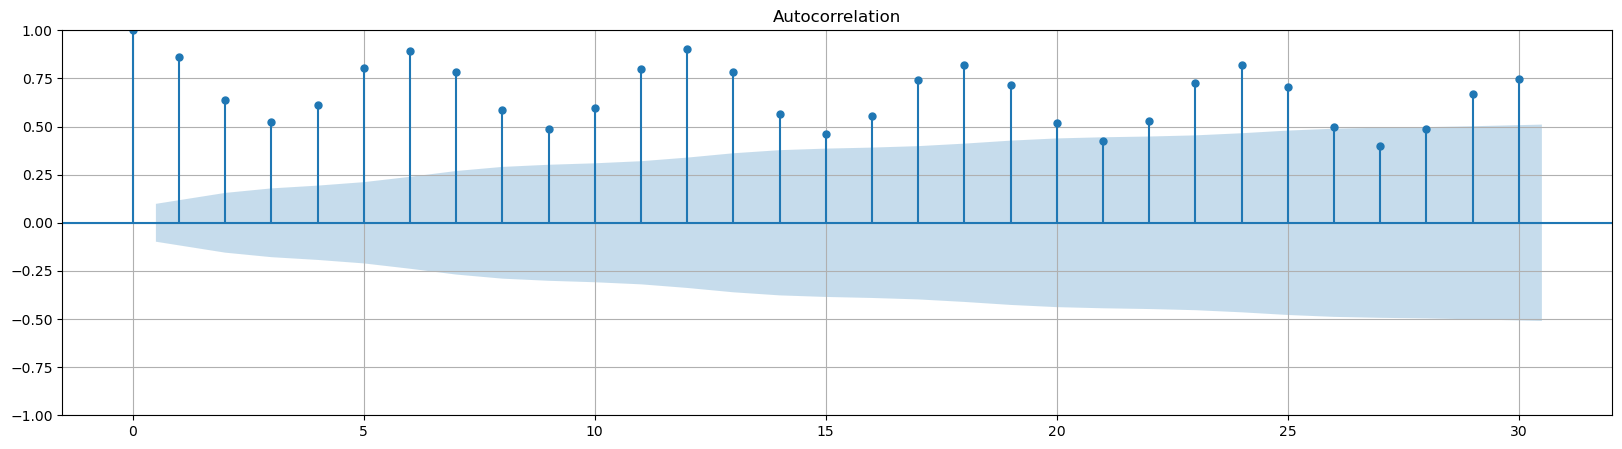

In [22]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(df['IPG2211A2N'], ax=plt.gca(), lags=30)
plt.show()
#not stationary

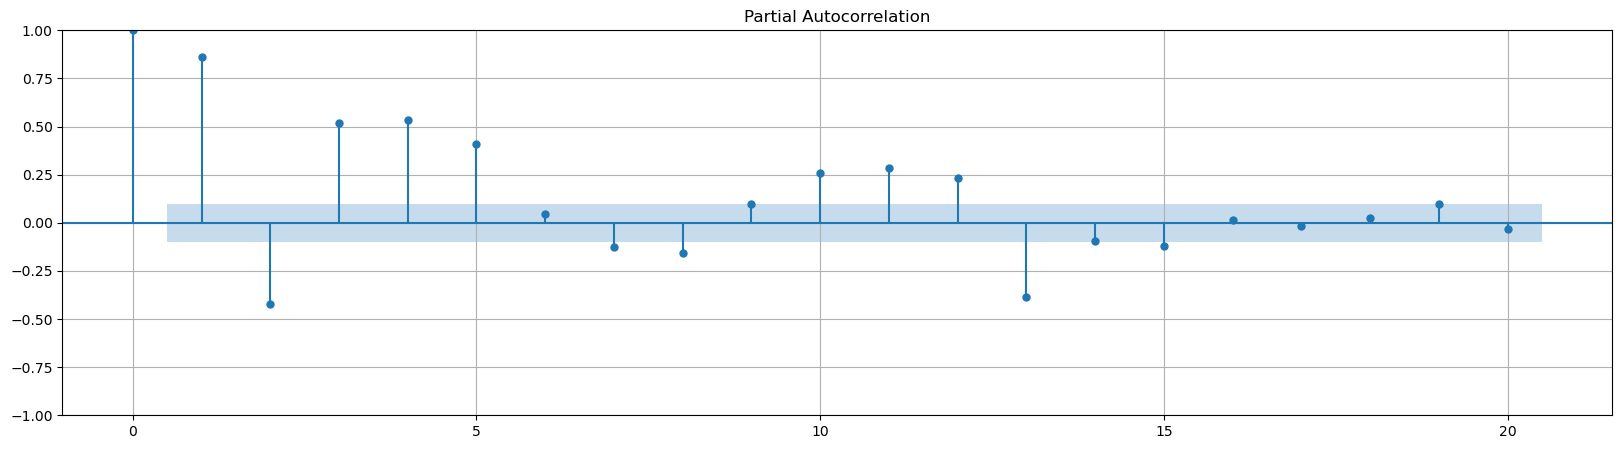

In [23]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(df['IPG2211A2N'], ax=plt.gca(), lags=20)
plt.show()
#not stationary

In [24]:
#To make the data stationary we do differencing

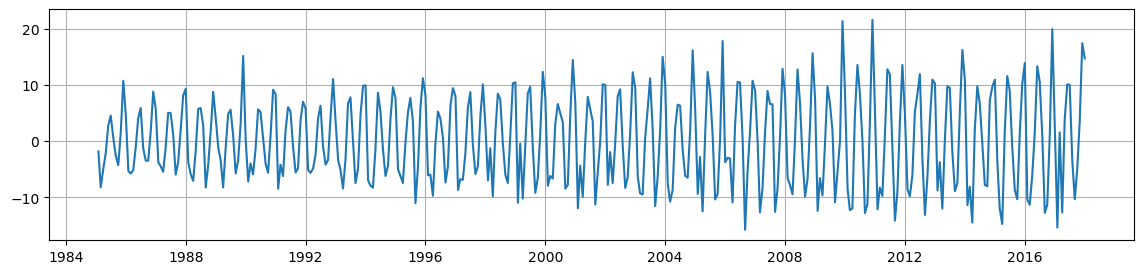

In [25]:
#First order non-seasonal differencing
diff = df['IPG2211A2N'].diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [26]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(diff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#is stationary

Results of the Dickey Fuller Test:
Test Statistic           -7.104891e+00
P-value                   4.077787e-10
#Lags used                1.400000e+01
Number of Observations    3.810000e+02
Critical Value(1%)       -3.447631e+00
Critical Value(5%)       -2.869156e+00
Critical Value(10%)      -2.570827e+00
dtype: float64


In [27]:
kp = kpss(diff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_8780\3781695736.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


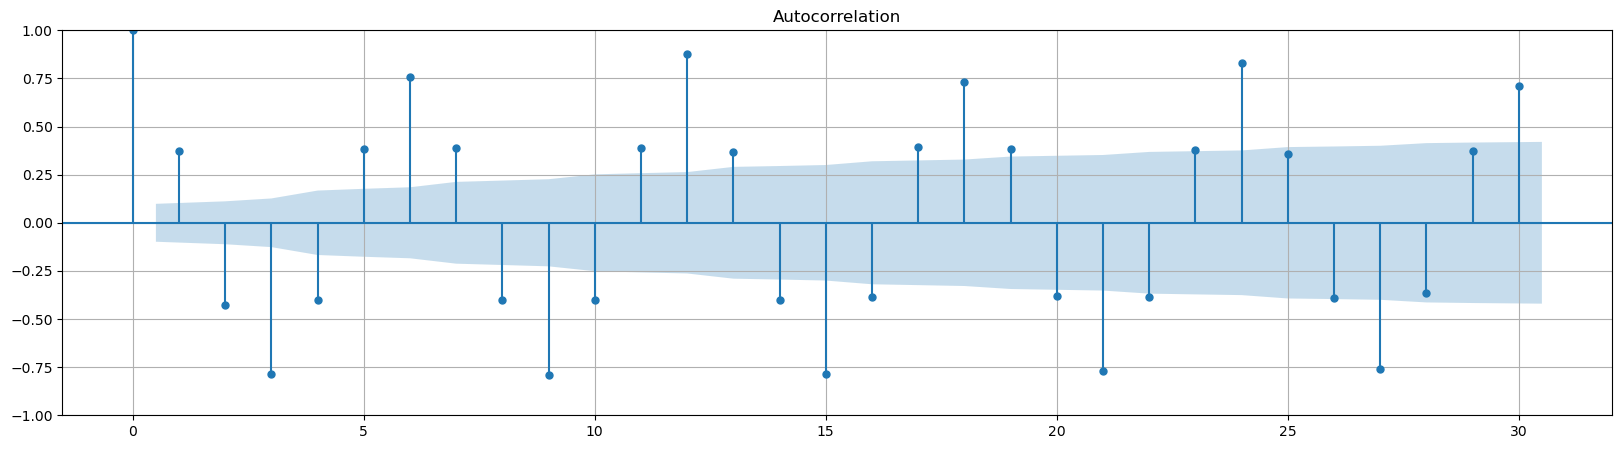

In [28]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff, ax=plt.gca(), lags=30)
plt.show()
#not stationary

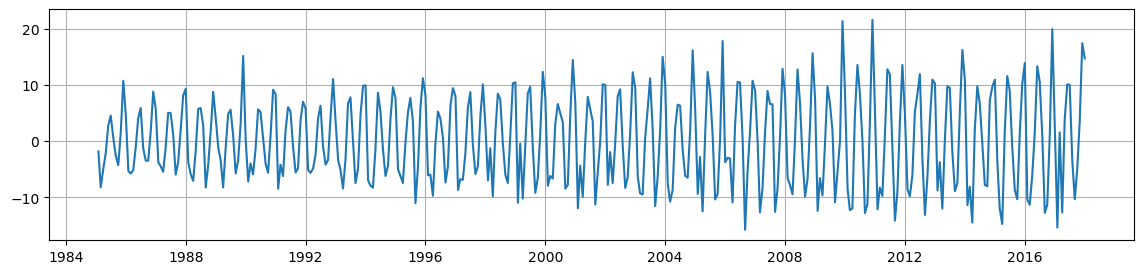

In [29]:
#Second order non-seasonal differencing
diff2 = df['IPG2211A2N'].diff().diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [30]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(diff2)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#is stationary

Results of the Dickey Fuller Test:
Test Statistic           -9.863042e+00
P-value                   4.183694e-17
#Lags used                1.700000e+01
Number of Observations    3.770000e+02
Critical Value(1%)       -3.447815e+00
Critical Value(5%)       -2.869237e+00
Critical Value(10%)      -2.570870e+00
dtype: float64


In [31]:
kp = kpss(diff2)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_8780\2399534368.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff2)


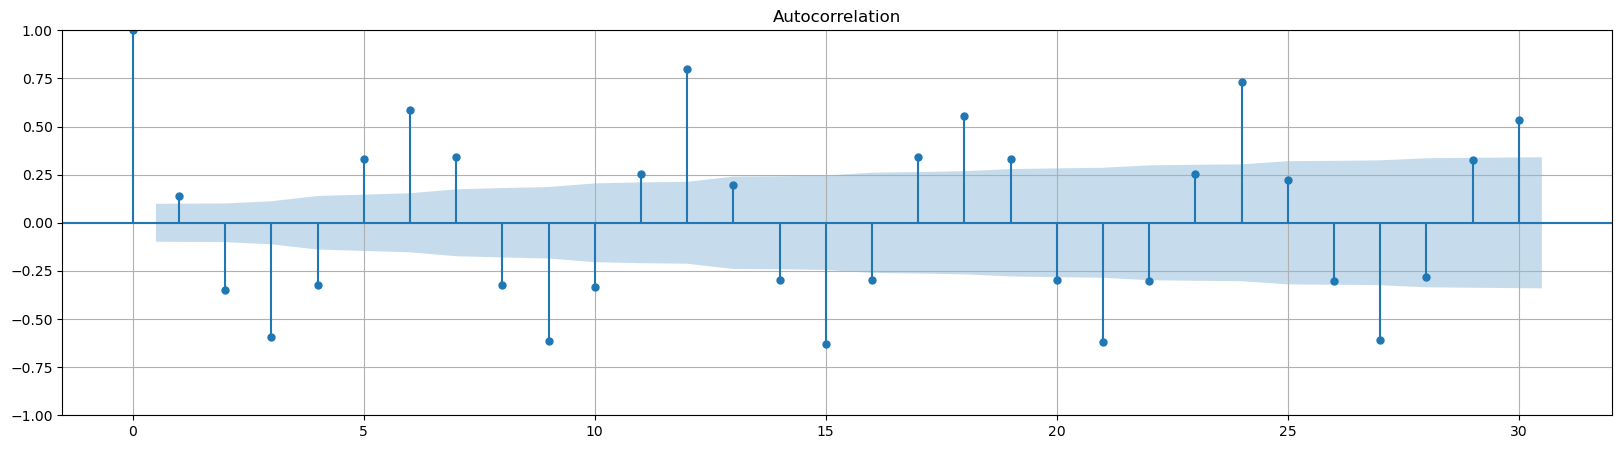

In [32]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff2, ax=plt.gca(), lags=30)
plt.show()
#not stationary

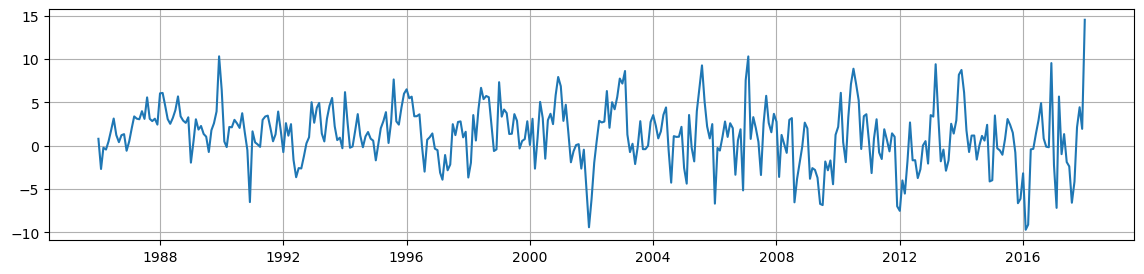

In [33]:
#First order Seasonal differencing
sdiff = df['IPG2211A2N'].diff(periods = 12).dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [34]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(sdiff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#is stationary

Results of the Dickey Fuller Test:
Test Statistic           -5.673482e+00
P-value                   8.812645e-07
#Lags used                1.200000e+01
Number of Observations    3.720000e+02
Critical Value(1%)       -3.448052e+00
Critical Value(5%)       -2.869341e+00
Critical Value(10%)      -2.570926e+00
dtype: float64


In [35]:
kp = kpss(sdiff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#not stationary

p-value for KPSS test (untransformed) =  0.024345634791440068


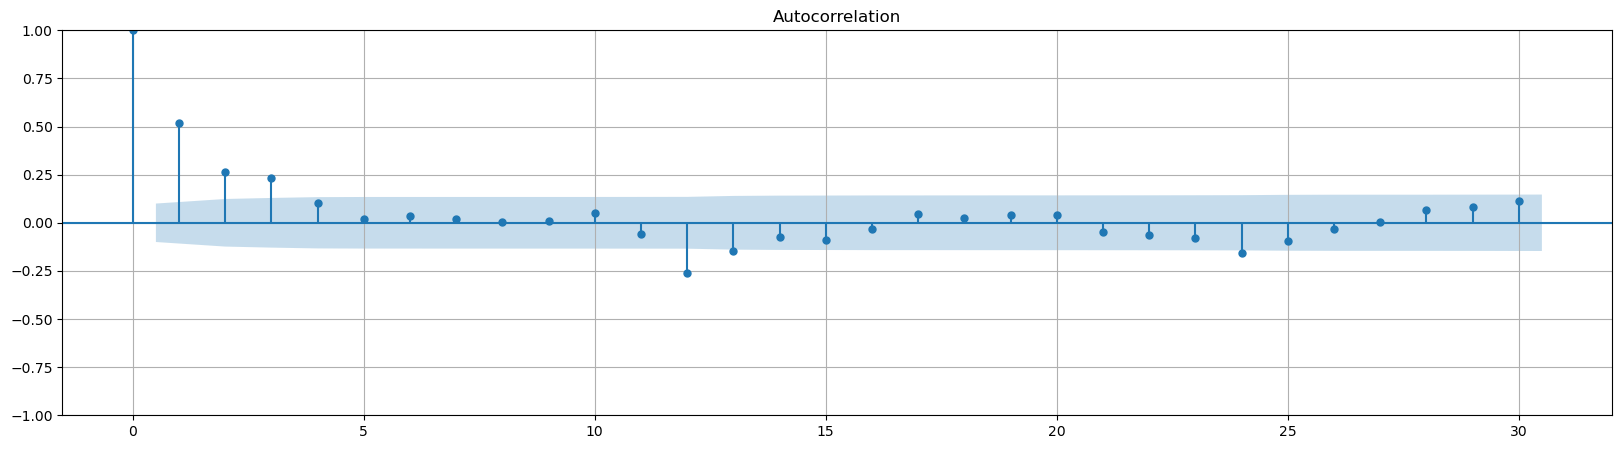

In [36]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sdiff, ax=plt.gca(), lags=30)
plt.show()
#not stationary

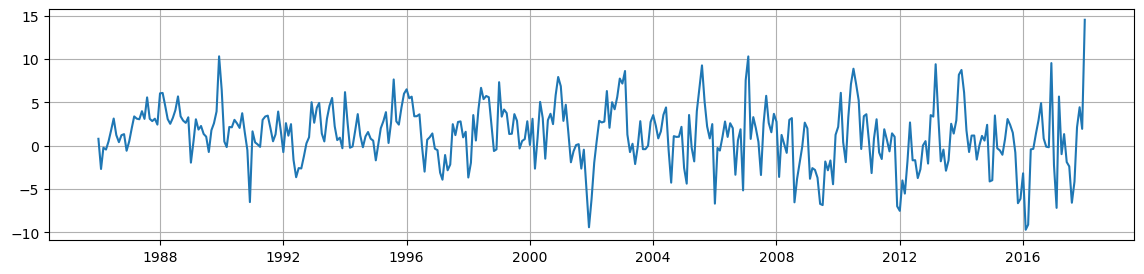

In [37]:
#Seasonal and NON-Seasonal differencing
sdiff = df['IPG2211A2N'].diff(periods = 12).dropna()
sddiff = sdiff.diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [38]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(sddiff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#is stationary

Results of the Dickey Fuller Test:
Test Statistic           -8.022039e+00
P-value                   2.063925e-12
#Lags used                1.500000e+01
Number of Observations    3.680000e+02
Critical Value(1%)       -3.448245e+00
Critical Value(5%)       -2.869426e+00
Critical Value(10%)      -2.570971e+00
dtype: float64


In [39]:
kp = kpss(sddiff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_8780\303679635.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


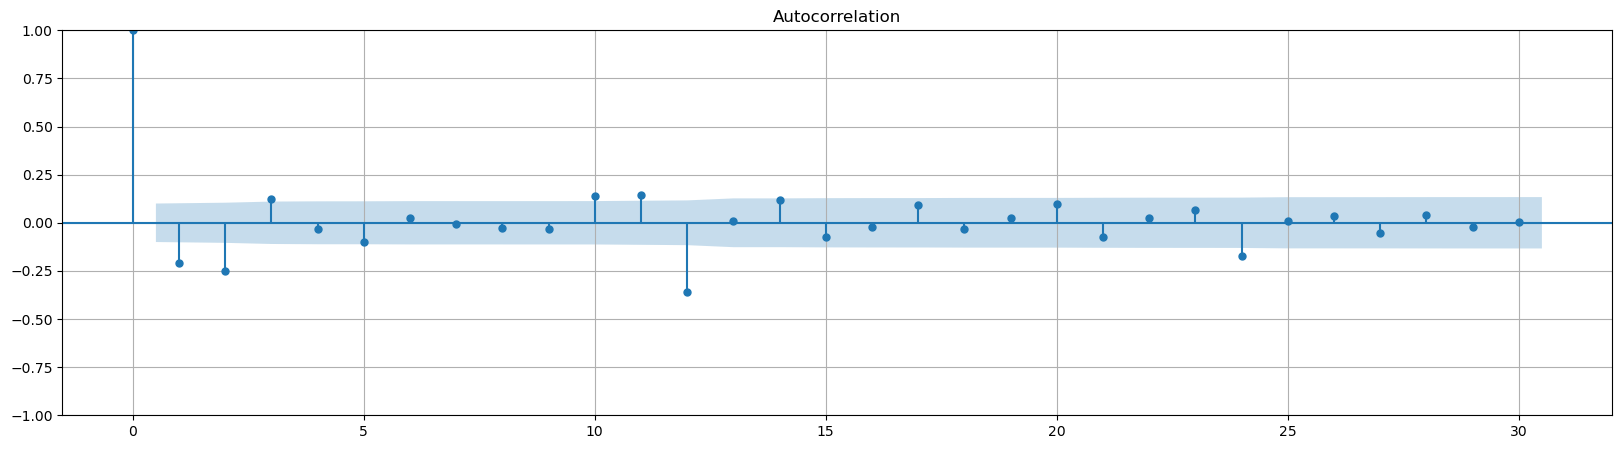

In [40]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sddiff, ax=plt.gca(), lags=30)
plt.show()
#is stationary

In [41]:
!pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable


In [42]:
!pip install pymannkendall pmdarima

Defaulting to user installation because normal site-packages is not writeable


In [46]:
import statsmodels.api as sm
model_1 =sm.tsa.statespace.SARIMAX(train_df['IPG2211A2N'], order=(1,1,1),seasonal_order=(1,1,1,12))
model_1_fit = model_1.fit()

print(model_1_fit.summary())                               

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         IPG2211A2N   No. Observations:                  277
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -575.211
Date:                            Mon, 03 Feb 2025   AIC                           1160.422
Time:                                    11:29:53   BIC                           1178.302
Sample:                                01-01-1985   HQIC                          1167.607
                                     - 01-01-2008                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4861      0.056      8.618      0.000       0.376       0.597
ma.L1         -0.9810      0.019   

In [48]:
from pmdarima.arima import auto_arima
model_auto_arima = auto_arima(df['IPG2211A2N'], seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1953.424, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2750.050, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2401.309, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2748.185, Time=0.04 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=0.94 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=inf, Time=0.95 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=1955.636, Time=2.06 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=inf, Time=2.13 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=2105.437, Time=0.39 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=2016.179, Time=1.67 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=inf, Time=1.97 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=3.67 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=1866.763, Time=1.11 sec
 ARIMA(1,1,2)(0,0,1)[12] intercept   : AIC=2265.6

In [50]:
import statsmodels.api as sm
model_2 =sm.tsa.statespace.SARIMAX(train_df['IPG2211A2N'], order=(1,1,2),seasonal_order=(1,0,1,12))
model_2_fit = model_2.fit()

print(model_2_fit.summary())   

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                      SARIMAX Results                                       
Dep. Variable:                           IPG2211A2N   No. Observations:                  277
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood                -612.292
Date:                              Mon, 03 Feb 2025   AIC                           1236.583
Time:                                      11:41:21   BIC                           1258.306
Sample:                                  01-01-1985   HQIC                          1245.300
                                       - 01-01-2008                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3050      0.132      2.320      0.020       0.047       0.563
ma.L1         -0.73

In [64]:
test_prediction1 = model_1_fit.forecast(len(test_df))
forcast_further1 = model_1_fit.forecast(len(test_df['IPG2211A2N'])+90)
forcast_further1 = forcast_further1[test_df.index.max():]
forcast_further1

2018-01-01    129.028578
2018-02-01    124.299441
2018-03-01    117.562077
2018-04-01    108.577938
2018-05-01    109.695474
                 ...    
2025-03-01    127.920577
2025-04-01    119.245520
2025-05-01    120.324609
2025-06-01    128.362982
2025-07-01    135.700235
Freq: MS, Name: predicted_mean, Length: 91, dtype: float64

In [56]:
test_prediction2 = model_2_fit.forecast(len(test_df))
forcast_further2 = model_2_fit.forecast(len(test_df['IPG2211A2N'])+90)
forcast_further2 = forcast_further2[test_df.index.max():]
forcast_further2

2018-01-01    129.028578
2018-02-01    124.299441
2018-03-01    117.562077
2018-04-01    108.577938
2018-05-01    109.695474
                 ...    
2025-03-01    127.920577
2025-04-01    119.245520
2025-05-01    120.324609
2025-06-01    128.362982
2025-07-01    135.700235
Freq: MS, Name: predicted_mean, Length: 91, dtype: float64

In [65]:
from sklearn.metrics import mean_absolute_percentage_error
mape_test1 = mean_absolute_percentage_error(test_df['IPG2211A2N'],test_prediction1)
print(mape_test1)

0.0862379804230265


In [62]:
mape_test2 = mean_absolute_percentage_error(test_df['IPG2211A2N'],test_prediction2)
print(mape_test2)

0.0862379804230265


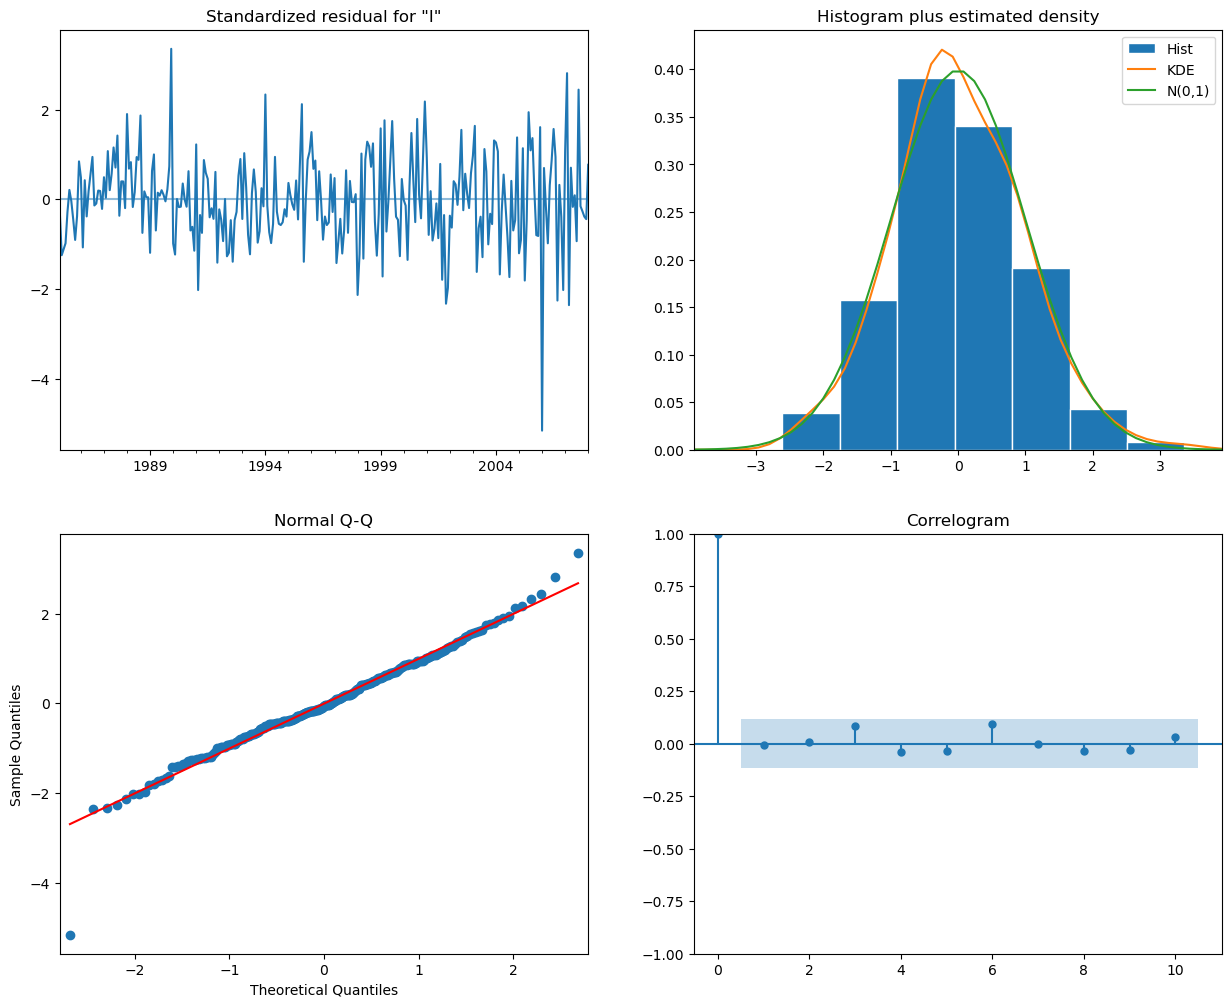

In [63]:
model_1_fit.plot_diagnostics(figsize=(15,12))
plt.show()

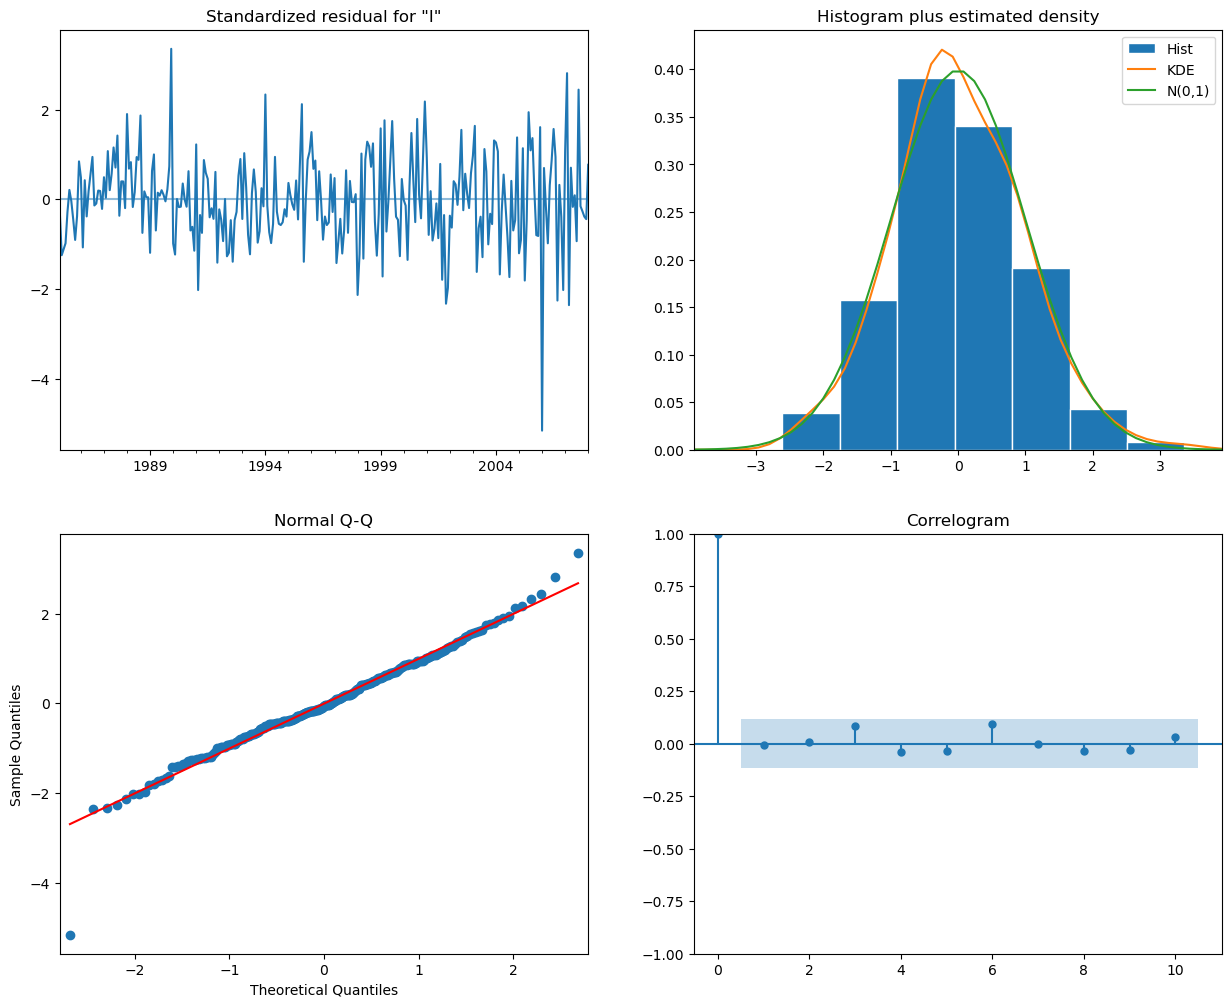

In [66]:
model_2_fit.plot_diagnostics(figsize=(15,12))
plt.show()

In [67]:
mape_test1 = mean_absolute_percentage_error(test_df['IPG2211A2N'],test_prediction1)
print(mape_test1)

0.0862379804230265
